# Geometric & Intensity Transformations


Apply classical image processing operations using Python and the `(PIL)` library. Complete both tasks and save your output images for comparison.


In [23]:
# Import the library
from PIL import Image, ImageOps
import numpy as np
import math

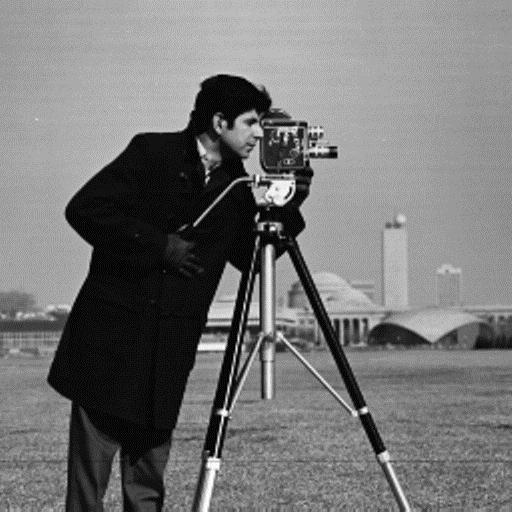

In [24]:
# ── Load image ────────────────────────────────────
img = Image.open("images/cameraman.jpg").convert("L")
img

### 1. Scale (increase size)
Double the image dimensions using `Image.resize()` with high-quality resampling `(LANCZOS)`.

In [25]:
# Get the size of the image
width, height = img.size

# scaling factors
cx = 2
cy = 2

print("Original size:", img.size)


Original size: (512, 512)


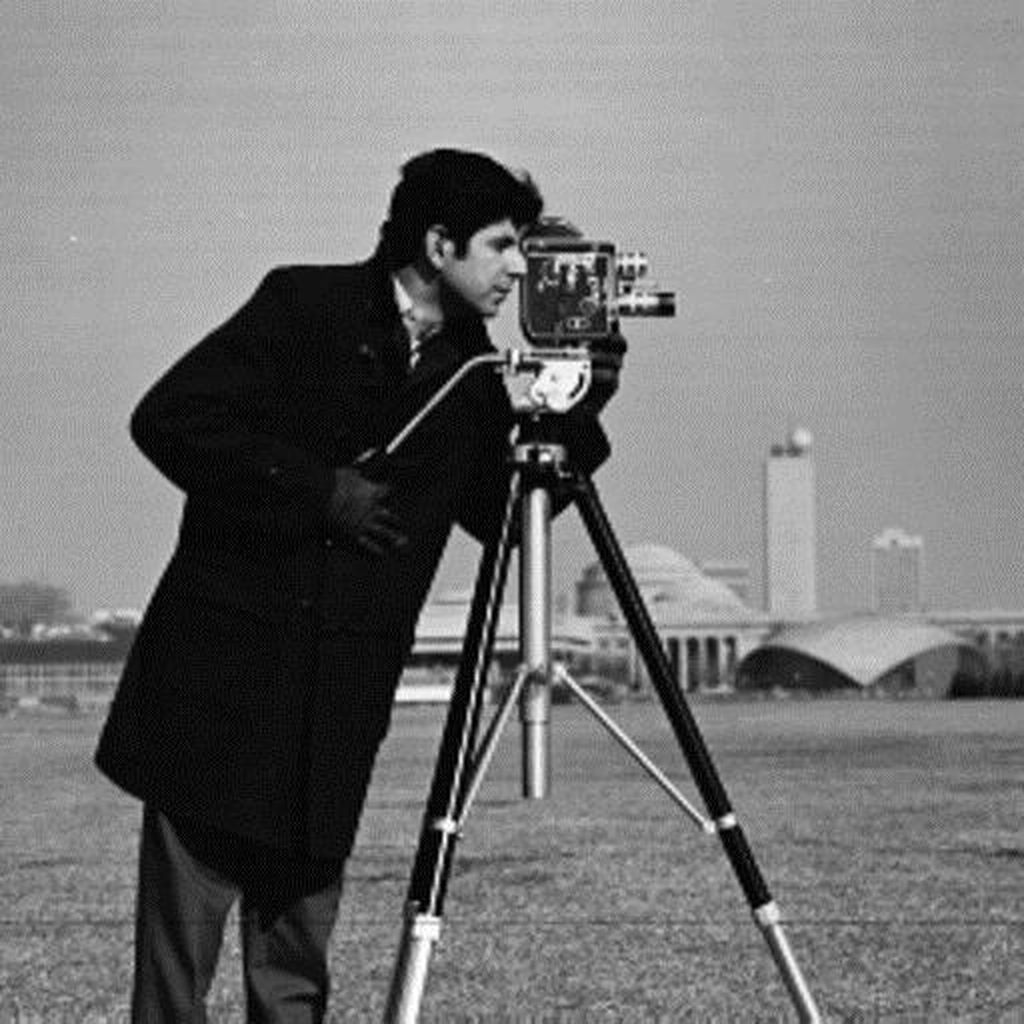

In [26]:
# ── 1. Increase size (scale ×2) ────────────────────

# Resize the image using PIL's built-in method
scaled_img = img.resize(
    (int(width * cx), int(height * cy)),
    Image.Resampling.LANCZOS
)

scaled_img


In [27]:

# Save the scaled image and print the sizes (The new image name should be "task1_1_scaled.jpg")
scaled_img.save("task1_1_scaled.jpg")

print("Original size:", img.size)
print("Scaled size:", scaled_img.size)

Original size: (512, 512)
Scaled size: (1024, 1024)


 non-uniform scale (cx=2, cy=1) → stretch horizontally only

In [28]:
# Non-uniform scaling factors
cx = 2
cy = 1

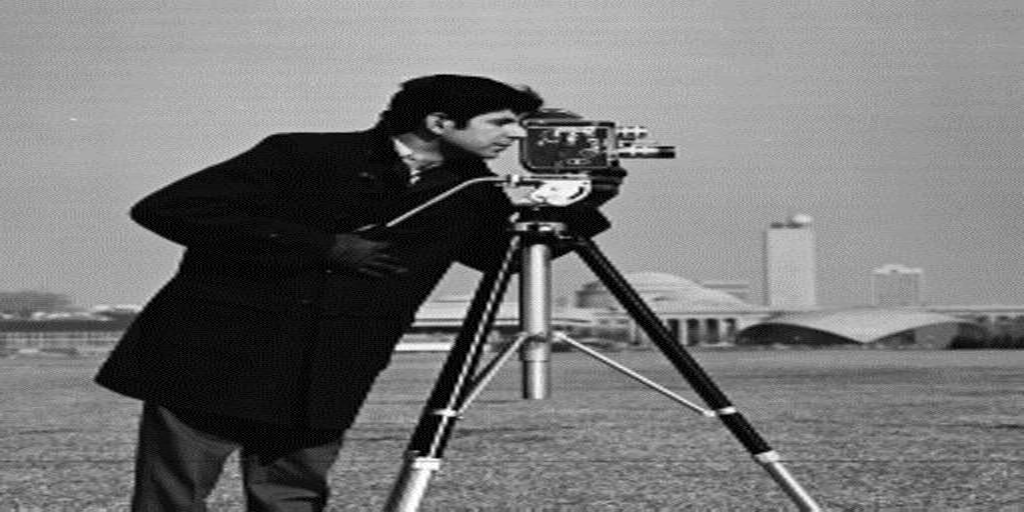

In [29]:
# Apply non-uniform scaling
non_uniform_scaled = img.resize(
    (int(width * cx), int(height * cy)),
    Image.Resampling.LANCZOS
)

non_uniform_scaled

In [30]:
# Print original and new sizes
print("Original size:", img.size)
print("Non-uniform scaled size:", non_uniform_scaled.size)

Original size: (512, 512)
Non-uniform scaled size: (1024, 512)


### 2. Rotate 120°
Rotate the image by 120 degrees, expanding the canvas to fit the full rotated image.

Original size: (512, 512)
Rotated size: (700, 700)


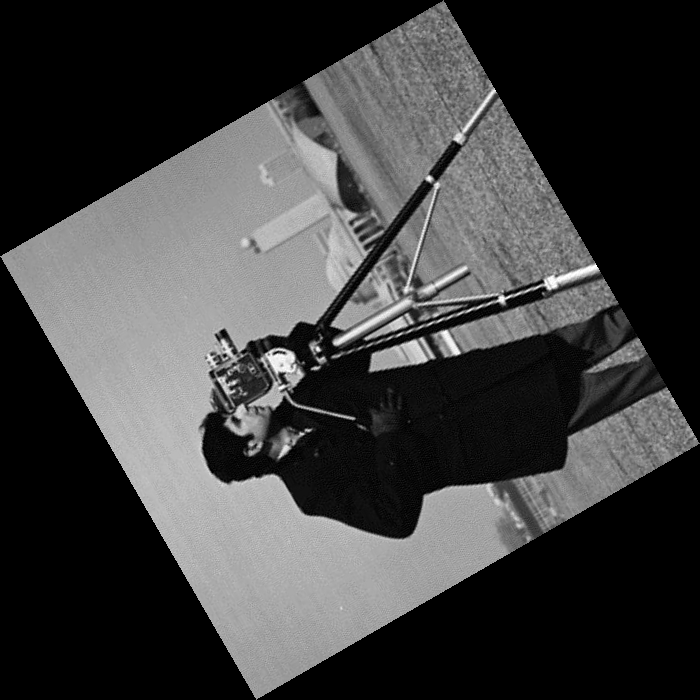

In [31]:
# ── 2. Rotate 120 degrees ──────────────────────────
# Save the scaled image and print the sizes (The new image name should be "task1_2_rotated.jpg")
rotated_img = img.rotate(
    120,
    expand=True,
    resample=Image.Resampling.BICUBIC
)

rotated_img.save("task1_2_rotated.jpg")

print("Original size:", img.size)
print("Rotated size:", rotated_img.size)

rotated_img

### 3. Shear

In [32]:
# -- c. Get the image dimensions ────────────────────
width, height = img.size

print("Width:", width)
print("Height:", height)

Width: 512
Height: 512


In [33]:
# -- d. define the shear matrix ──────────────────────────
# Choose X-axis or Y-axis shear. The shear factor controls how much the image slants — start with 0.5 then experiment.
shear_factor = 0.5

shx = shear_factor
shy = 0

new_width = int(width + abs(shx) * height)
new_height = height

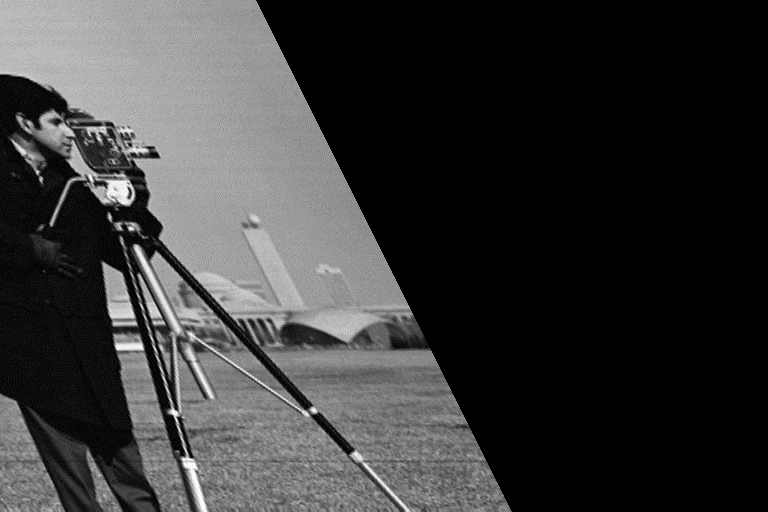

In [34]:
# -- e. Apply the shear transformation to the image ──────────────────────────
# PIL's transform() takes the inverse affine matrix:
# [ 1    shx   tx ]
# [ shy  1     ty ]
sheared_img = img.transform(
    (new_width, new_height),
    Image.Transform.AFFINE,
    (1, -shx, abs(shx) * height, 0, 1, 0),
    resample=Image.Resampling.BICUBIC
)

sheared_img

In [35]:
# -- f. Save the sheared image(The new image name should be "task1_3_sheared.jpg")
sheared_img.save("task1_3_sheared.jpg")

print("Original size:", img.size)
print("Sheared size:", sheared_img.size)

Original size: (512, 512)
Sheared size: (768, 512)


### Experiment and compare
Try these:

— Change shear factor from 0.5 to 0.1, 0.3, 0.8 and compare results

— Switch from X-axis to Y-axis shear matrix

— Update the canvas multiplier to match your new factor

— Try combining X and Y shear in one matrix

X-axis shear factor = 0.1


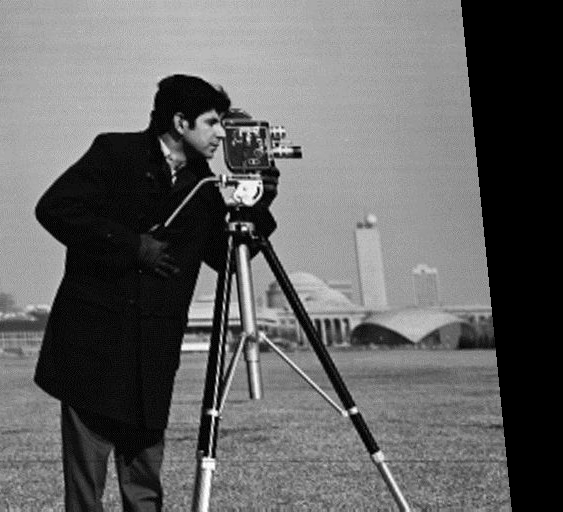

X-axis shear factor = 0.3


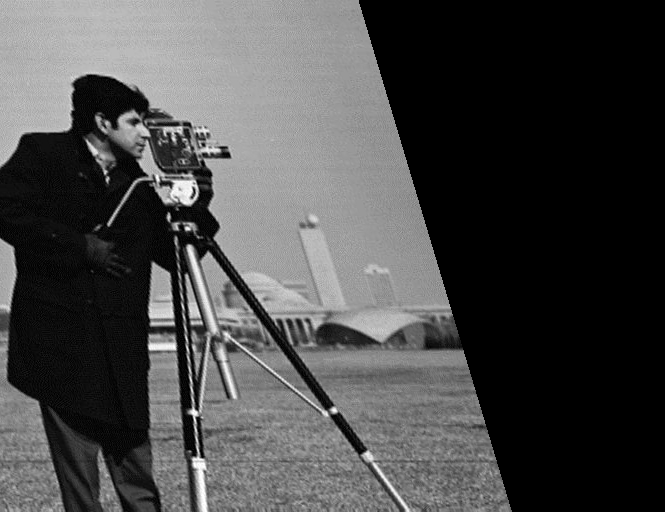

X-axis shear factor = 0.8


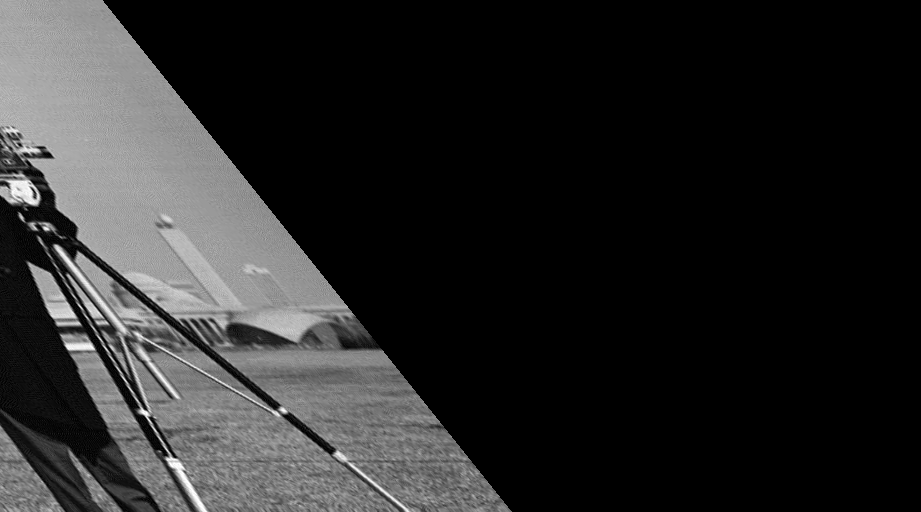

Y-axis shear:


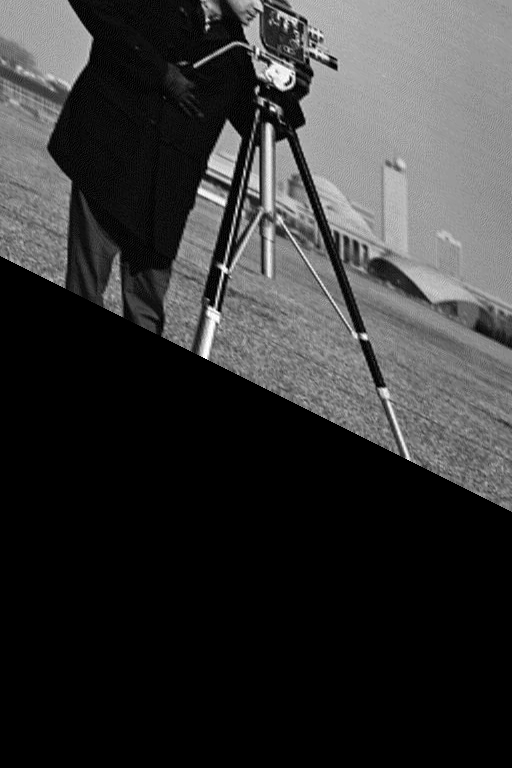

Original size: (512, 512)
Y-shear canvas size: (512, 768)
Combined X and Y shear:


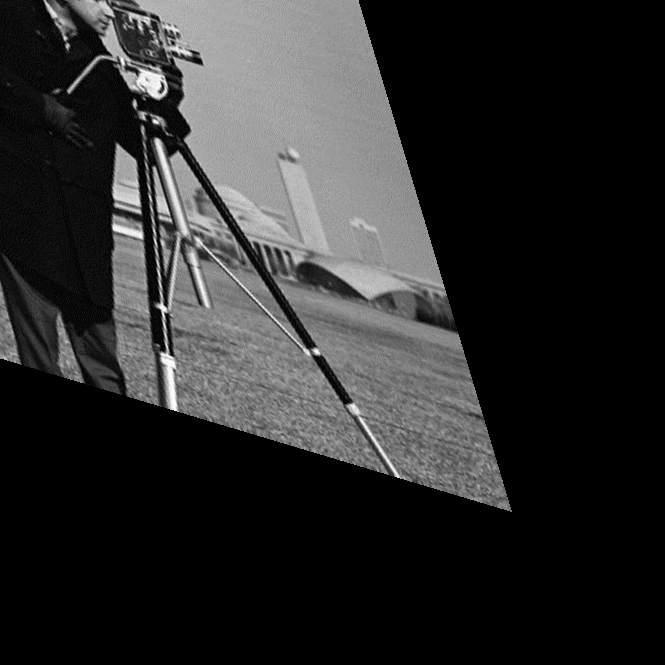

In [36]:
# 1: Change shear factor from 0.5 to 0.1, 0.3, 0.8
factors = [0.1, 0.3, 0.8]

for factor in factors:

    new_width = int(width + abs(factor) * height)

    sheared = img.transform(
        (new_width, height),
        Image.Transform.AFFINE,
        (1, -factor, abs(factor) * height, 0, 1, 0),
        resample=Image.Resampling.BICUBIC
    )

    print("X-axis shear factor =", factor)
    display(sheared)


# 2: Switch from X-axis to Y-axis shear

shear_factor = 0.5

new_height = int(height + abs(shear_factor) * width)

y_sheared = img.transform(
    (width, new_height),
    Image.Transform.AFFINE,
    (1, 0, 0, -shear_factor, 1, abs(shear_factor) * width),
    resample=Image.Resampling.BICUBIC
)

print("Y-axis shear:")
display(y_sheared)


# 3: Canvas size is updated according to the shear factor

print("Original size:", img.size)
print("Y-shear canvas size:", y_sheared.size)


# 4: Combine X and Y shear in one matrix

shx = 0.3
shy = 0.3

new_width = int(width + abs(shx) * height)
new_height = int(height + abs(shy) * width)

xy_sheared = img.transform(
    (new_width, new_height),
    Image.Transform.AFFINE,
    (1, -shx, abs(shx) * height,
     -shy, 1, abs(shy) * width),
    resample=Image.Resampling.BICUBIC
)

print("Combined X and Y shear:")
display(xy_sheared)

# Intensity Transformations
Negative · Log · Power Law (Gamma)

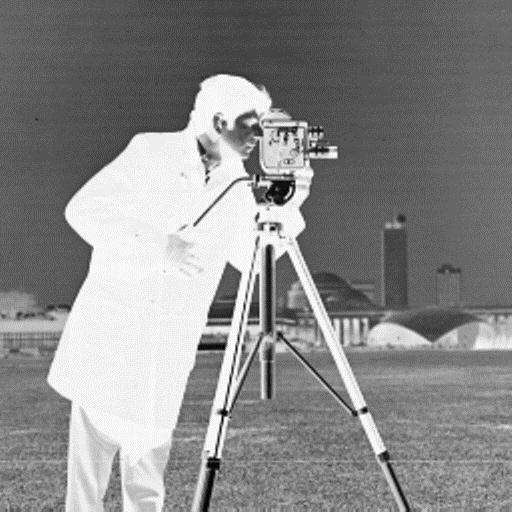

In [37]:

# ── 1. Negative ────────────────────────────────────
# Method 1: NumPy array manipulation
arr = np.array(img)

negative_arr = 255 - arr

negative_img = Image.fromarray(negative_arr.astype(np.uint8))

negative_img

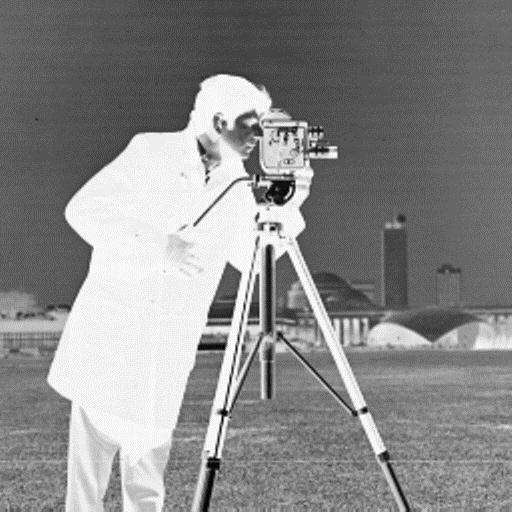

In [38]:
# Method 2: PIL's ImageOps
negative_img_pil = ImageOps.invert(img)

negative_img_pil

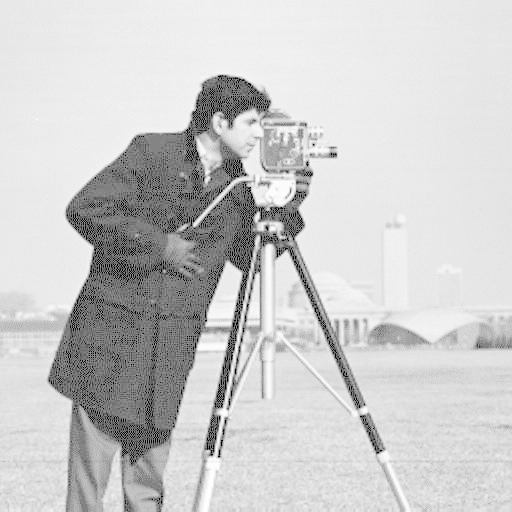

In [39]:
# ── 2. Log transformation ──────────────────────────

# s = c · log(1 + r) --> We need to find c.
# We want the maximum output value (s) to be 255 when the maximum input value (r) is 255:
# 255 = c · log(1 + 255)
# c = 255 / log(1 + 255)
arr = np.array(img).astype(np.float32)

c = 255 / np.log(1 + 255)


# Apply the log transformation to each pixel
log_transformed_arr = c * np.log(1 + arr)

log_transformed_arr = np.uint8(log_transformed_arr)

log_transformed_img = Image.fromarray(log_transformed_arr)

log_transformed_img

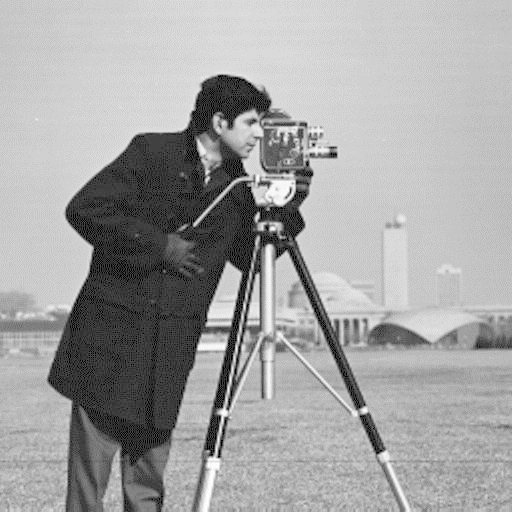

In [40]:

# ── 3. Power-law / Gamma correction ───────────────
gamma = 0.5

arr = np.array(img).astype(np.float32) / 255.0

gamma_corrected_arr = 255 * (arr ** gamma)

gamma_corrected_arr = np.uint8(gamma_corrected_arr)

gamma_corrected_img = Image.fromarray(gamma_corrected_arr)

gamma_corrected_img

In [41]:
gamma_corrected_img.save("gamma_corrected.jpg")

print("Gamma value:", gamma)

Gamma value: 0.5
